# 📓 Regresión Lineal — WeatherStack ETL
Análisis exploratorio y modelos predictivos conectados a PostgreSQL local.

**Variable objetivo (y):** `sensacion_termica`  
**Features (X):** `temperatura`, `humedad`, `velocidad_viento`  
**Registros:** 1 000 filas × 5 ciudades colombianas

## ⚙️ Celda 1 — Importaciones

In [2]:
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scripts.database import engine

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ Librerías importadas correctamente')
print(f'   pandas      {pd.__version__}')
print(f'   numpy       {np.__version__}')
print(f'   seaborn     {sns.__version__}')
print(f'   statsmodels {sm.__version__}')

✅ Librerías importadas correctamente
   pandas      2.3.3
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.6


## 🗄️ Celda 2 — Carga de datos desde PostgreSQL

In [3]:
QUERY = """
SELECT
    c.nombre        AS ciudad,
    r.temperatura,
    r.sensacion_termica,
    r.humedad,
    r.velocidad_viento,
    r.fecha_extraccion
FROM registros_clima r
JOIN ciudades c ON r.ciudad_id = c.id
ORDER BY r.fecha_extraccion
"""

df = pd.read_sql(QUERY, engine)

print(f'✅ Datos cargados exitosamente desde PostgreSQL')
print(f'   Filas    : {df.shape[0]:,}')
print(f'   Columnas : {df.shape[1]}')
print(f'\n📋 Primeras filas:')
df.head()

✅ Datos cargados exitosamente desde PostgreSQL
   Filas    : 1,004
   Columnas : 6

📋 Primeras filas:


,ciudad,temperatura,sensacion_termica,humedad,velocidad_viento,fecha_extraccion
0,Bogota,12.8,12.2,93.6,6.5,2026-03-12 02:21:36.825445
1,Cali,26.3,24.7,46.0,6.9,2026-03-12 02:21:36.830083
2,Bogota,16.6,15.3,66.9,6.1,2026-03-12 05:21:36.824758
3,Cartagena,31.7,30.0,69.6,32.8,2026-03-12 05:21:36.835529
4,Cartagena,28.4,26.4,42.4,39.2,2026-03-12 06:21:36.834462


## 🔍 Celda 3 — Inspección inicial

In [4]:
print('=' * 50)
print('  INFORMACIÓN GENERAL DEL DATASET')
print('=' * 50)
print(df.info())
print('\n📊 Valores nulos por columna:')
print(df.isnull().sum())
print('\n🏙️  Ciudades en el dataset:')
print(df['ciudad'].value_counts())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ciudad             1004 non-null   object        
 1   temperatura        1004 non-null   float64       
 2   sensacion_termica  1004 non-null   float64       
 3   humedad            1004 non-null   float64       
 4   velocidad_viento   1004 non-null   float64       
 5   fecha_extraccion   1004 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 47.2+ KB
None

📊 Valores nulos por columna:
ciudad               0
temperatura          0
sensacion_termica    0
humedad              0
velocidad_viento     0
fecha_extraccion     0
dtype: int64

🏙️  Ciudades en el dataset:
ciudad
Bogota          201
Cali            201
Barranquilla    201
Medellin        201
Cartagena       200
Name: count, dtype: int64


## 📊 Celda 4 — Estadísticas descriptivas

In [5]:
vars_num = ['temperatura', 'sensacion_termica', 'humedad', 'velocidad_viento']
desc = df[vars_num].describe().round(2)
print('📊 ESTADÍSTICAS DESCRIPTIVAS')
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
       temperatura  sensacion_termica  humedad  velocidad_viento
count      1004.00            1004.00  1004.00           1004.00
mean         24.37              22.90    67.37             21.96
std           6.51               6.56    15.81             10.09
min          10.00               7.40    40.00              4.00
25%          20.40              18.70    54.15             13.10
50%          25.40              24.00    67.20             21.60
75%          29.50              27.80    80.62             30.00
max          35.00              34.50    95.00             40.00


## 📈 Celda 5 — Histogramas de distribución

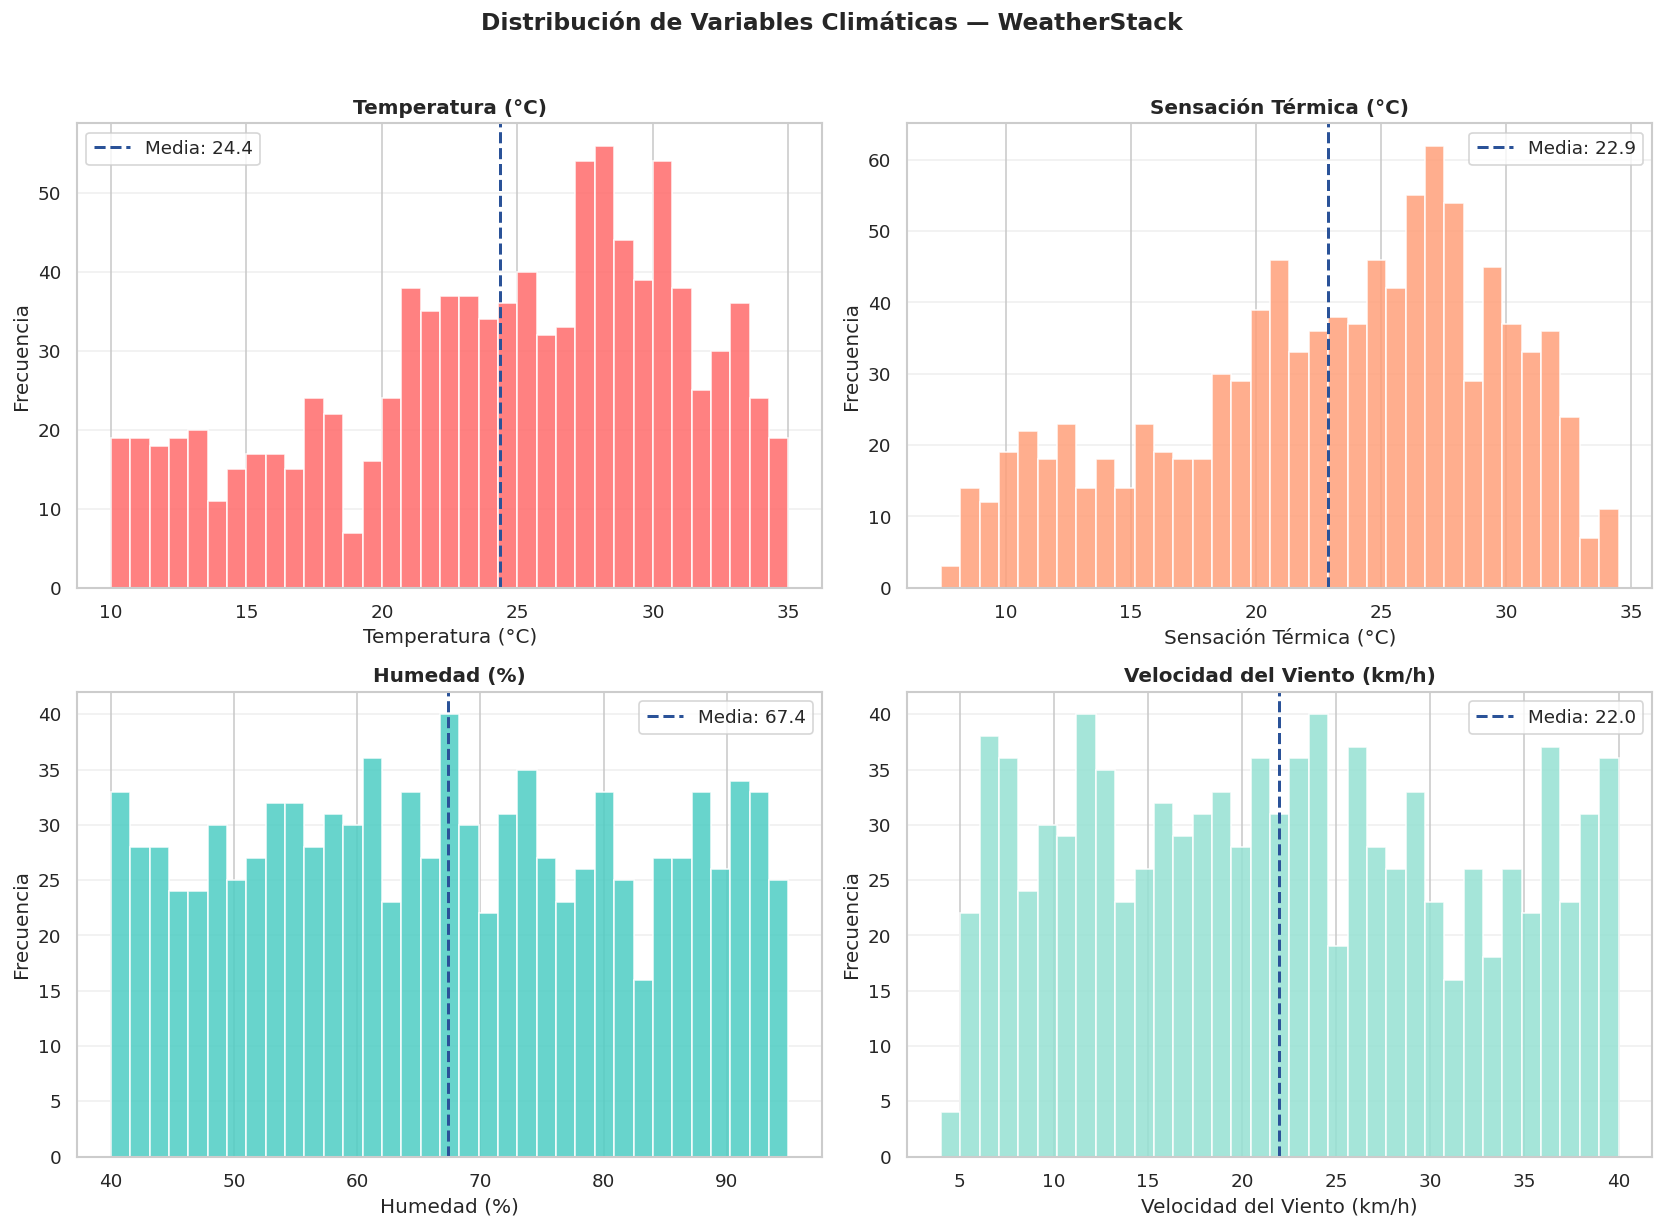

✅ Guardado: data/graficas/eda_distribuciones.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Climáticas — WeatherStack',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'temperatura':       ('Temperatura (°C)',           '#ff6b6b'),
    'sensacion_termica': ('Sensación Térmica (°C)',      '#ffa07a'),
    'humedad':           ('Humedad (%)',                 '#4ecdc4'),
    'velocidad_viento':  ('Velocidad del Viento (km/h)', '#95e1d3'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    ax.hist(df[col], bins=35, color=color, edgecolor='white', alpha=0.85)
    media = df[col].mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:.1f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: data/graficas/eda_distribuciones.png')

## 📦 Celda 6 — Boxplots por ciudad

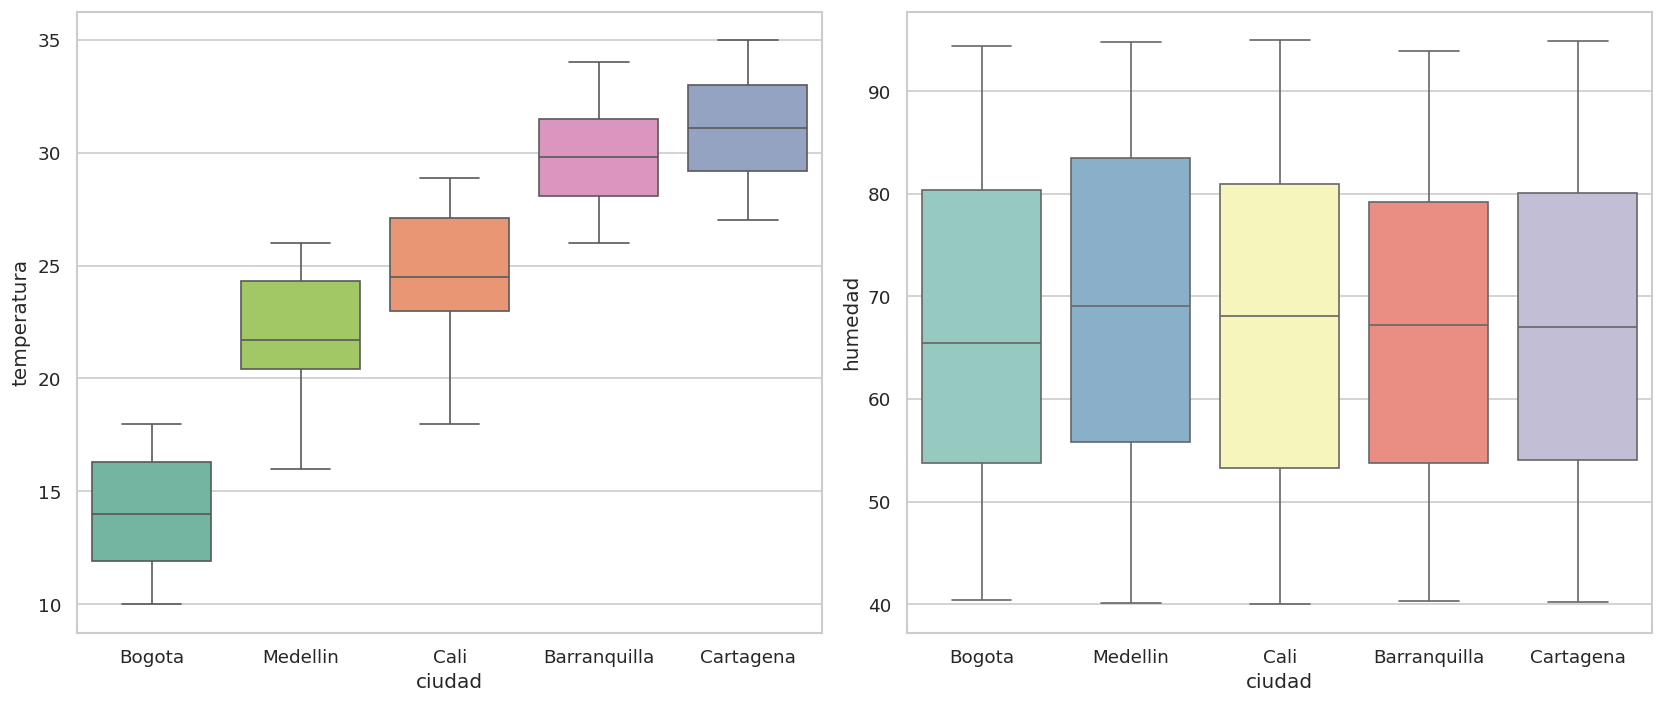

✅ Guardado: data/graficas/eda_boxplots_ciudad.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
orden = df.groupby('ciudad')['temperatura'].median().sort_values().index

sns.boxplot(data=df, x='ciudad', y='temperatura', hue='ciudad', 
            order=orden, palette='Set2', legend=False, ax=axes[0])

sns.boxplot(data=df, x='ciudad', y='humedad', hue='ciudad', 
            order=orden, palette='Set3', legend=False, ax=axes[1])

plt.tight_layout()
plt.savefig('../data/graficas/eda_boxplots_ciudad.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: data/graficas/eda_boxplots_ciudad.png')

## 🔥 Celda 7 — Matriz de correlación

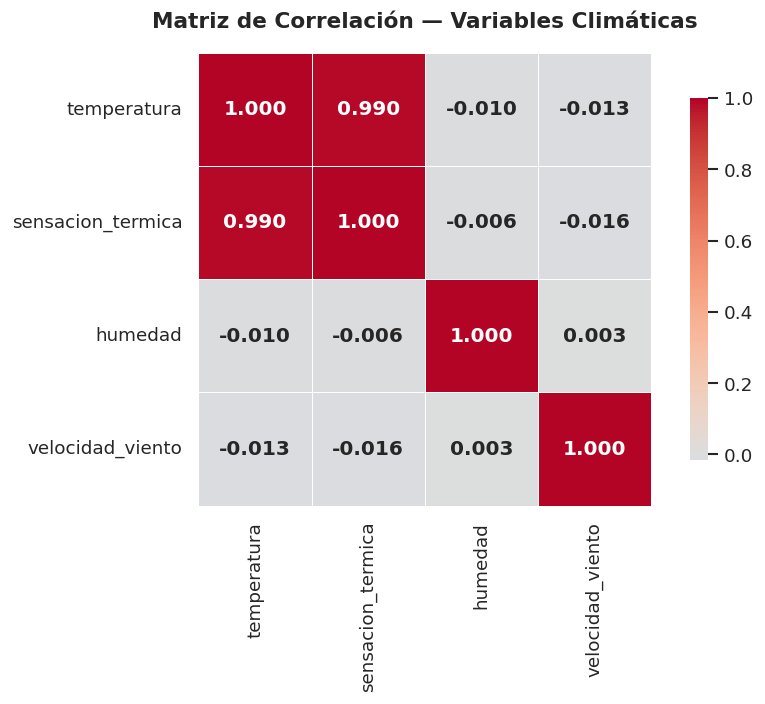


📊 Correlación con sensacion_termica:
temperatura         0.9904
humedad            -0.0058
velocidad_viento   -0.0162
Name: sensacion_termica, dtype: float64
✅ Guardado: data/graficas/eda_correlacion.png


In [10]:
corr = df[vars_num].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.6, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Matriz de Correlación — Variables Climáticas',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/graficas/eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Correlación con sensacion_termica:')
print(corr['sensacion_termica'].drop('sensacion_termica').sort_values(ascending=False).round(4))
print('✅ Guardado: data/graficas/eda_correlacion.png')

## 🔵 Celda 8 — Scatter plots bivariados

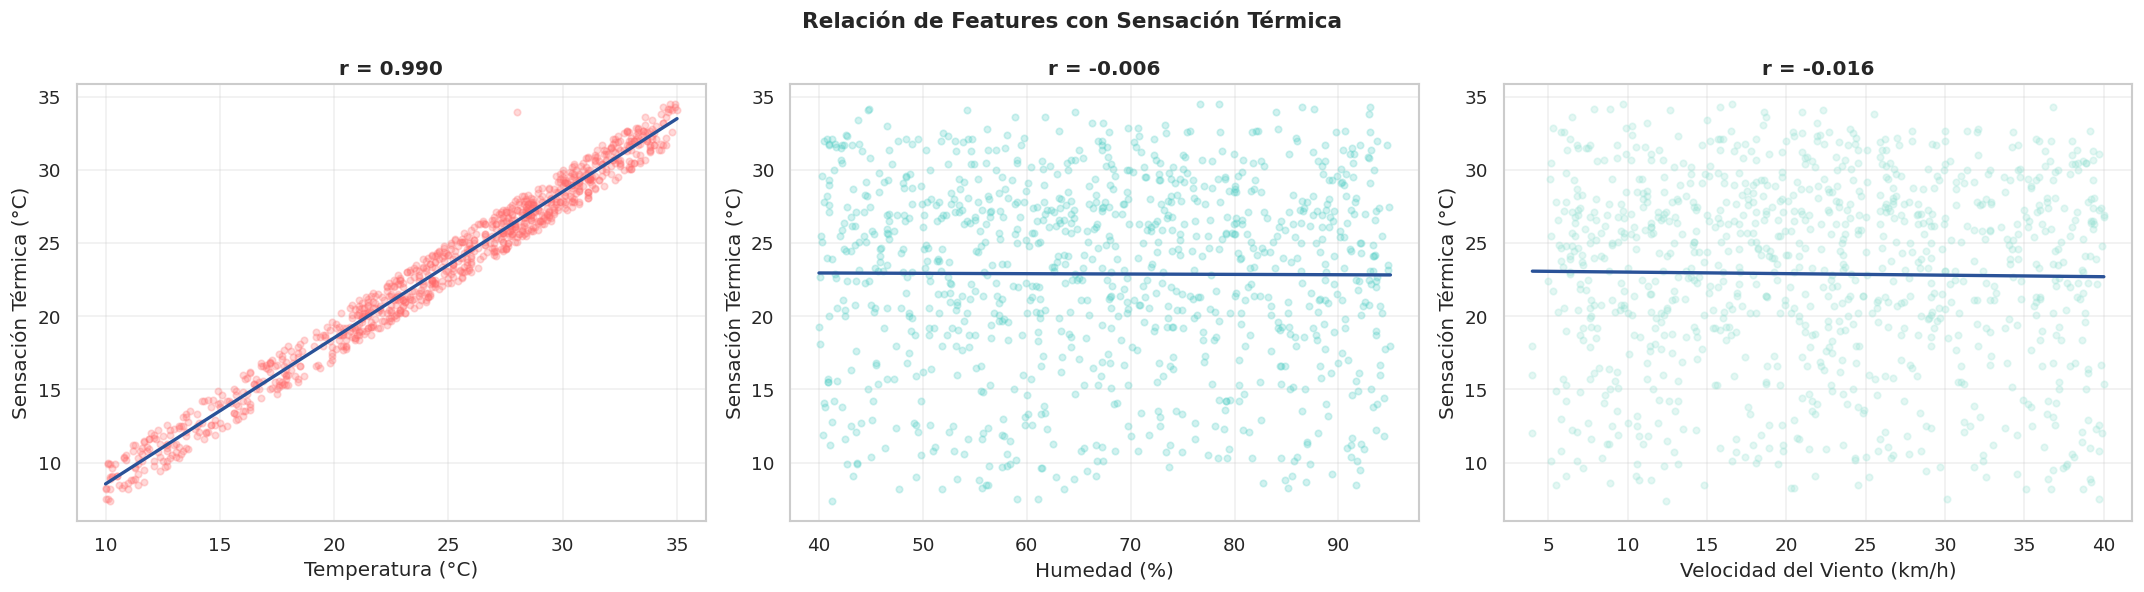

✅ Guardado: data/graficas/eda_scatter.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Features con Sensación Térmica', fontsize=13, fontweight='bold')

pares = [
    ('temperatura',      'Temperatura (°C)',           '#ff6b6b'),
    ('humedad',          'Humedad (%)',                 '#4ecdc4'),
    ('velocidad_viento', 'Velocidad del Viento (km/h)', '#95e1d3'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    ax.scatter(df[feature], df['sensacion_termica'], alpha=0.25, s=15, color=color)
    z  = np.polyfit(df[feature], df['sensacion_termica'], 1)
    p  = np.poly1d(z)
    xp = np.linspace(df[feature].min(), df[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)
    r  = df[[feature, 'sensacion_termica']].corr().iloc[0, 1]
    ax.set_title(f'r = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Sensación Térmica (°C)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: data/graficas/eda_scatter.png')

## ✂️ Celda 9 — Split Train / Test (modelo simple)

In [12]:
X_simple = df[['temperatura']].values
y        = df['sensacion_termica'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f'Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)')
print(f'Test : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y)*100:.0f}%)')

Train: 803 muestras (80%)
Test : 201 muestras  (20%)


## 🤖 Celda 10 — Entrenamiento modelo simple (scikit-learn)

In [13]:
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)
y_pred_simple = modelo_simple.predict(X_test)

print(f'Intercepto  β₀ : {modelo_simple.intercept_:.4f}')
print(f'Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}')
print(f'\nEcuación: sensacion_termica = {modelo_simple.intercept_:.3f} + {modelo_simple.coef_[0]:.3f} × temperatura')

Intercepto  β₀ : -1.4232
Coeficiente β₁ : 0.9987

Ecuación: sensacion_termica = -1.423 + 0.999 × temperatura


## 📉 Celda 11 — Recta de regresión

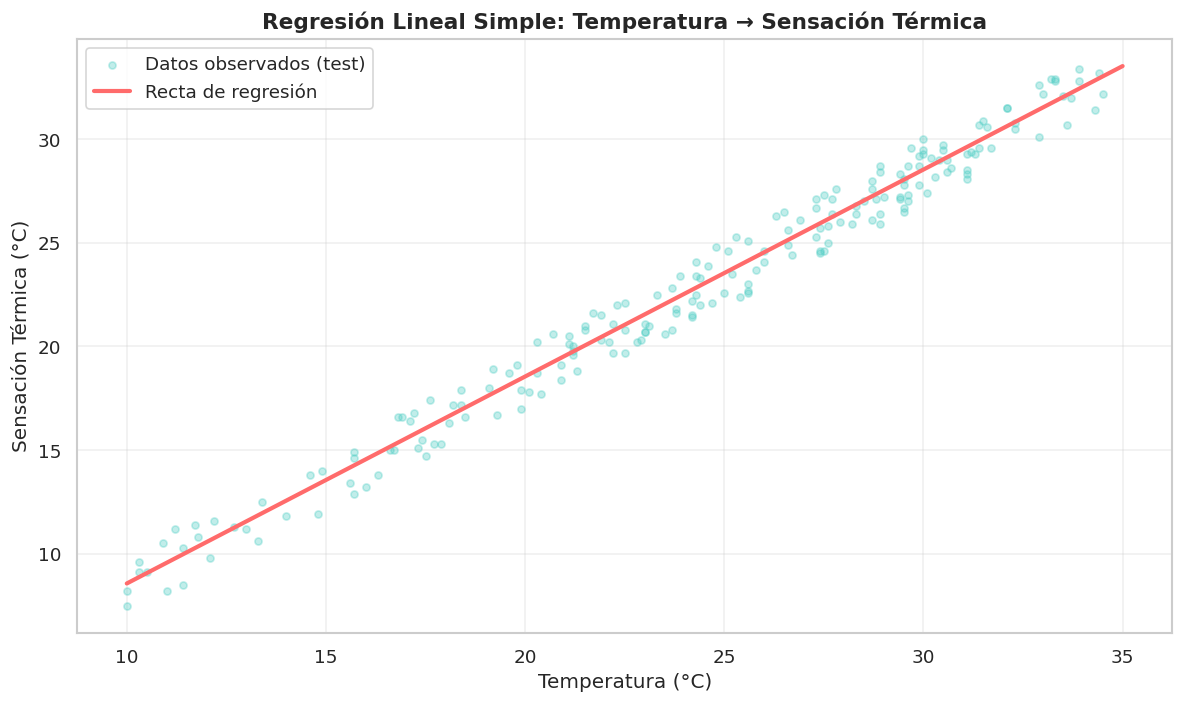

✅ Guardado: data/graficas/regresion_simple.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_test, y_test, alpha=0.35, s=18, color='#4ecdc4', label='Datos observados (test)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line), color='#ff6b6b', linewidth=2.5, label='Recta de regresión')
ax.set_xlabel('Temperatura (°C)', fontsize=12)
ax.set_ylabel('Sensación Térmica (°C)', fontsize=12)
ax.set_title('Regresión Lineal Simple: Temperatura → Sensación Térmica',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: data/graficas/regresion_simple.png')

## 📐 Celda 12 — Métricas modelo simple

In [15]:
r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print('=' * 48)
print('    MÉTRICAS — REGRESIÓN LINEAL SIMPLE')
print('=' * 48)
print(f'  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)')
print(f'  MSE  (error cuadrático med)  : {mse:.4f}')
print(f'  RMSE (raíz del MSE)          : {rmse:.4f}')
print(f'  MAE  (error absoluto medio)  : {mae:.4f}')
print('=' * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   (coef. determinación)  : 0.9801  (98.01%)
  MSE  (error cuadrático med)  : 0.8296
  RMSE (raíz del MSE)          : 0.9108
  MAE  (error absoluto medio)  : 0.8011


## 📋 Celda 13 — Resumen OLS statsmodels (modelo simple)

In [16]:
X_ols = sm.add_constant(df['temperatura'])
modelo_ols_simple = sm.OLS(df['sensacion_termica'], X_ols).fit()
print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:      sensacion_termica   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                 5.152e+04
Date:                Sat, 11 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:59:00   Log-Likelihood:                -1325.4
No. Observations:                1004   AIC:                             2655.
Df Residuals:                    1002   BIC:                             2665.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.4412      0.111    -12.985      

## 🔬 Celda 14 — Normalidad de residuos (Shapiro-Wilk + Q-Q Plot)

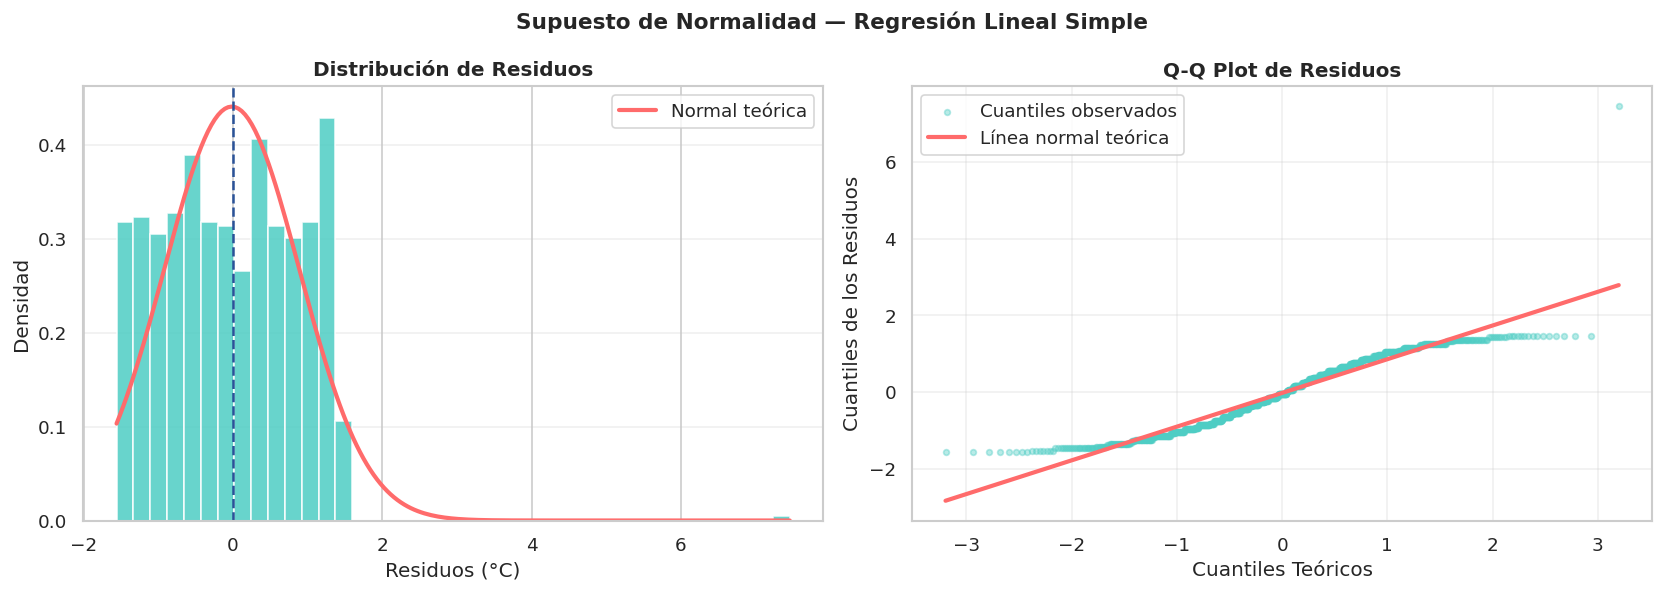


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9341
   p-value       : 0.000000
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)
   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot
✅ Guardado: data/graficas/normalidad_simple.png


In [17]:
y_pred_all = modelo_simple.predict(df[['temperatura']].values)
residuos   = df['sensacion_termica'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple', fontsize=13, fontweight='bold')

axes[0].hist(residuos, bins=40, color='#4ecdc4', edgecolor='white', density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (°C)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4', label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal teórica')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_simple.png', dpi=150, bbox_inches='tight')
plt.show()

muestra_sw = residuos if len(residuos) <= 5000 else np.random.default_rng(42).choice(residuos, 5000, replace=False)
stat_sw, p_sw = stats.shapiro(muestra_sw)
print(f'\n🔬 Test de Shapiro-Wilk:')
print(f'   Estadístico W : {stat_sw:.4f}')
print(f'   p-value       : {p_sw:.6f}')
if p_sw > 0.05:
    print('   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)')
else:
    print('   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)')
    print('   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot')
print('✅ Guardado: data/graficas/normalidad_simple.png')

## 📐 Celda 15 — Homocedasticidad (Breusch-Pagan + LOWESS)

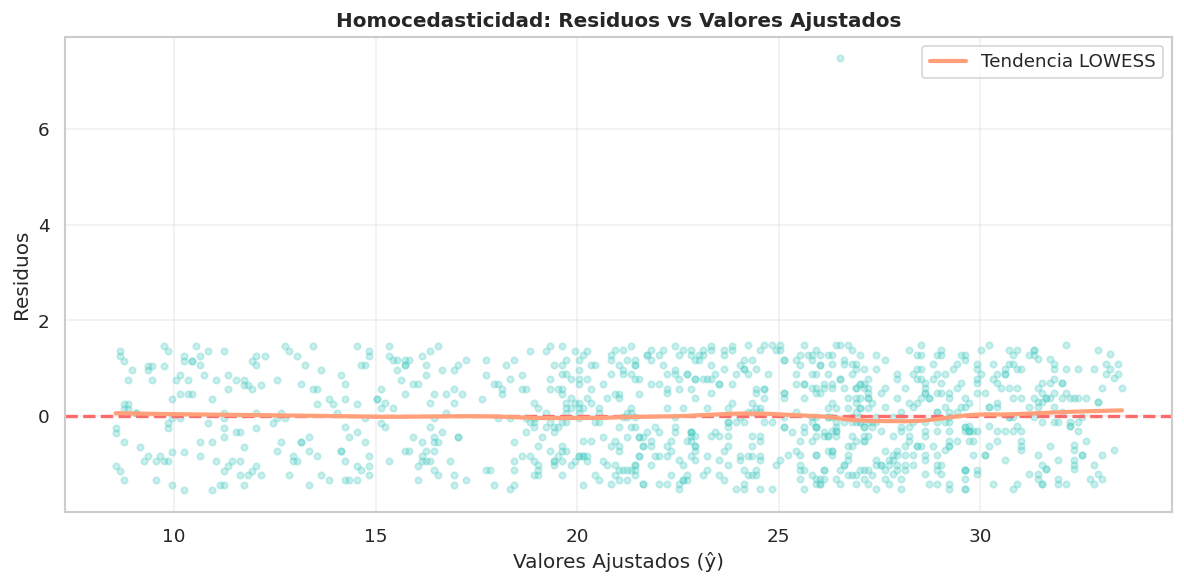


🔬 Test de Breusch-Pagan:
   Estadístico LM : 0.0000
   p-value        : 0.996782
   Conclusión     : ✅ Homocedasticidad (p > 0.05)
✅ Guardado: data/graficas/homoc_simple.png


In [18]:
residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.30, s=15, color='#4ecdc4')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='#ffa07a', linewidth=2.5, label='Tendencia LOWESS')
plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/homoc_simple.png', dpi=150, bbox_inches='tight')
plt.show()

lm, lm_p, fval, fp = het_breuschpagan(residuos_ols, modelo_ols_simple.model.exog)
print(f'\n🔬 Test de Breusch-Pagan:')
print(f'   Estadístico LM : {lm:.4f}')
print(f'   p-value        : {lm_p:.6f}')
if lm_p > 0.05:
    print('   Conclusión     : ✅ Homocedasticidad (p > 0.05)')
else:
    print('   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)')
print('✅ Guardado: data/graficas/homoc_simple.png')

## 🔢 Celda 16 — Modelo múltiple (entrenamiento)

In [19]:
FEATURES = ['temperatura', 'humedad', 'velocidad_viento']
X_multi  = df[FEATURES].values
y        = df['sensacion_termica'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)
y_pred_multi = modelo_multi.predict(X_test_m)

print(f'Intercepto  β₀              : {modelo_multi.intercept_:.4f}')
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f'Coeficiente {feat:>18} : {coef:.4f}')

Intercepto  β₀              : -1.5736
Coeficiente        temperatura : 0.9986
Coeficiente            humedad : 0.0033
Coeficiente   velocidad_viento : -0.0031


## 📊 Celda 17 — Gráfica de coeficientes

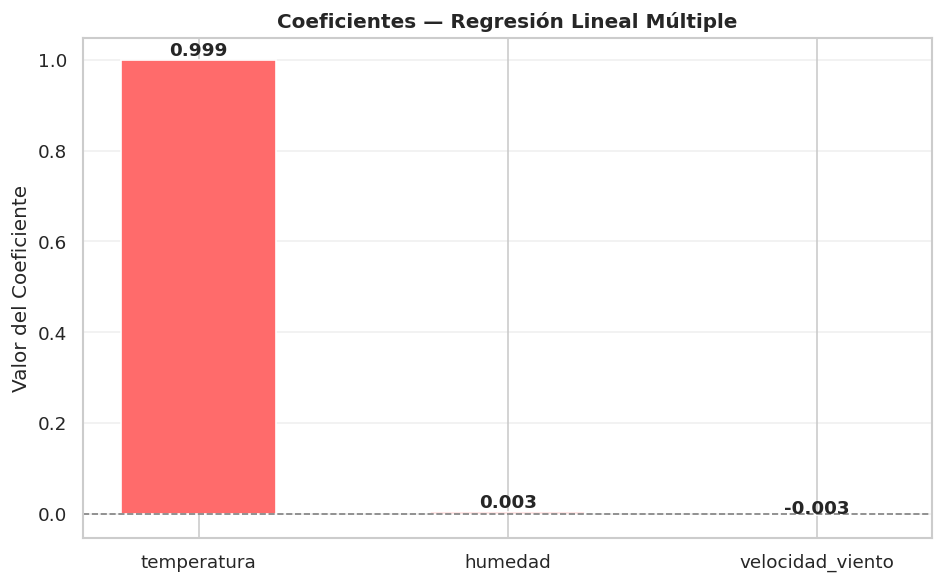

✅ Guardado: data/graficas/coeficientes_multi.png


In [20]:
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(FEATURES, modelo_multi.coef_, color=colores, edgecolor='white', width=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes — Regresión Lineal Múltiple', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')
for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.002 if coef >= 0 else -0.005
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
            f'{coef:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_multi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: data/graficas/coeficientes_multi.png')

## 📐 Celda 18 — Métricas modelo múltiple

In [21]:
r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print('=' * 48)
print('  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE')
print('=' * 48)
print(f'  R²   : {r2_m:.4f}  ({r2_m*100:.2f}%)')
print(f'  MSE  : {mse_m:.4f}')
print(f'  RMSE : {rmse_m:.4f}')
print(f'  MAE  : {mae_m:.4f}')
print('=' * 48)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  R²   : 0.9798  (97.98%)
  MSE  : 0.8419
  RMSE : 0.9175
  MAE  : 0.8076


## 📋 Celda 19 — OLS statsmodels (modelo múltiple)

In [22]:
X_ols_m = sm.add_constant(df[FEATURES])
modelo_ols_multi = sm.OLS(df['sensacion_termica'], X_ols_m).fit()
print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:      sensacion_termica   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                 1.716e+04
Date:                Sat, 11 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:01:32   Log-Likelihood:                -1324.6
No. Observations:                1004   AIC:                             2657.
Df Residuals:                    1000   BIC:                             2677.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.5124      0.178  

## 🔗 Celda 20 — VIF (Multicolinealidad)

In [23]:
X_vif = df[FEATURES].copy()
vif_data = pd.DataFrame({
    'Variable': FEATURES,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data['VIF']      = vif_data['VIF'].round(3)
vif_data['Criterio'] = vif_data['VIF'].apply(
    lambda v: '✅ Sin multicolinealidad (VIF < 5)' if v < 5
    else ('⚠️  Moderada (5 ≤ VIF < 10)' if v < 10 else '❌ Severa (VIF ≥ 10)')
)
print('\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)')
print('=' * 60)
print(vif_data.to_string(index=False))
print('=' * 60)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
        Variable   VIF                    Criterio
     temperatura 9.341 ⚠️  Moderada (5 ≤ VIF < 10)
         humedad 9.977 ⚠️  Moderada (5 ≤ VIF < 10)
velocidad_viento 5.009 ⚠️  Moderada (5 ≤ VIF < 10)


## 🔬 Celda 21 — Diagnósticos completos modelo múltiple

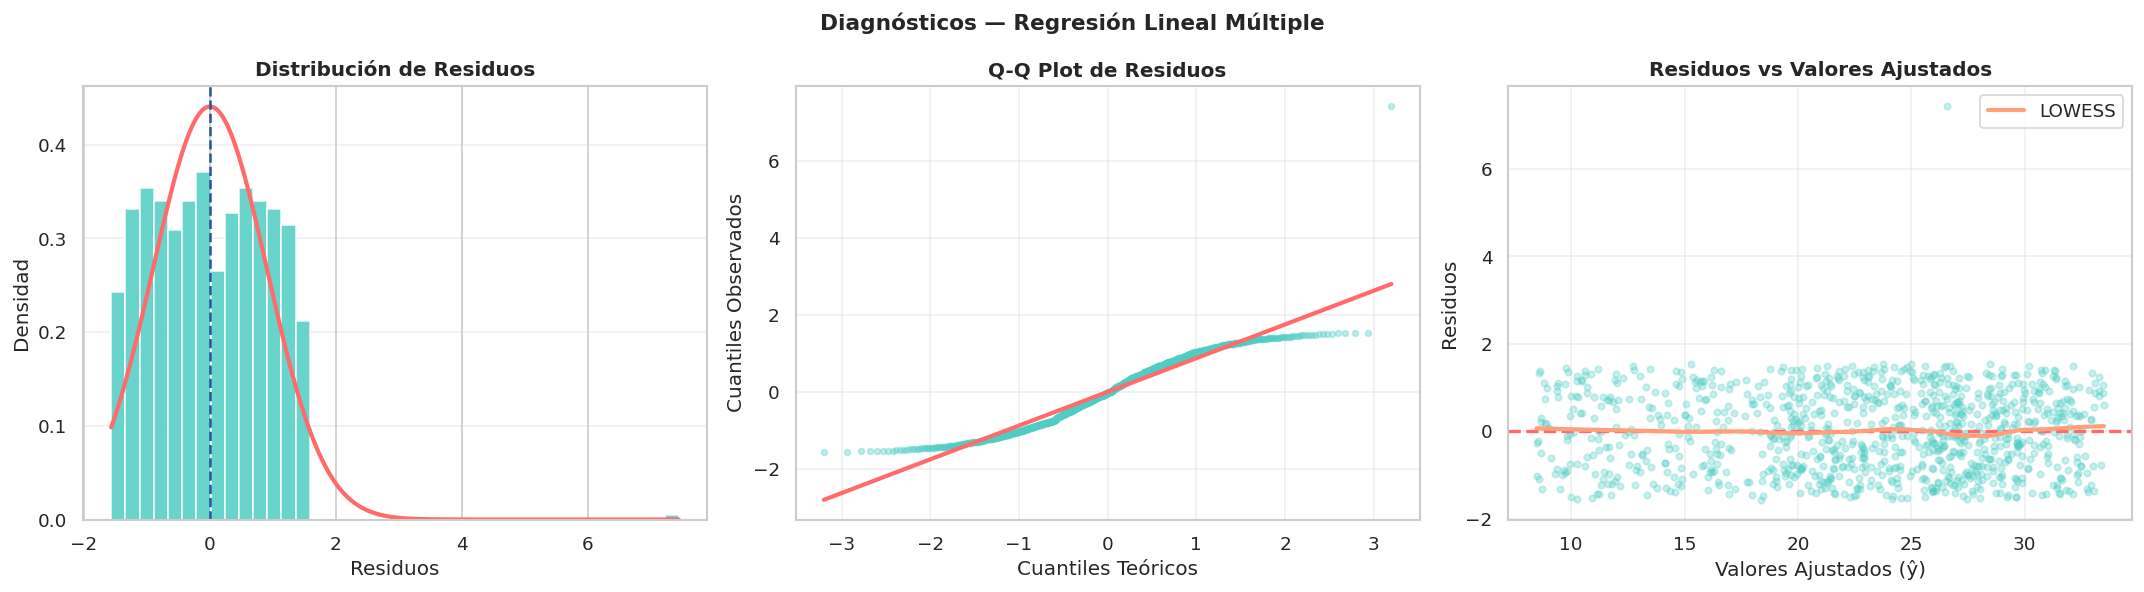


🔬 Shapiro-Wilk  p=0.000000 → ⚠️  Se rechaza normalidad
🔬 Breusch-Pagan p=0.645495 → ✅ Homocedasticidad OK
✅ Guardado: data/graficas/diagnosticos_multi.png


In [24]:
residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple', fontsize=13, fontweight='bold')

axes[0].hist(residuos_m, bins=40, color='#4ecdc4', edgecolor='white', density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()), color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i, color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

axes[2].scatter(ajustados_m, residuos_m, alpha=0.30, s=15, color='#4ecdc4')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1], color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/diagnosticos_multi.png', dpi=150, bbox_inches='tight')
plt.show()

muestra_m = residuos_m if len(residuos_m) <= 5000 else np.random.default_rng(42).choice(residuos_m, 5000, replace=False)
stat_sw_m, p_sw_m = stats.shapiro(muestra_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(modelo_ols_multi.resid, modelo_ols_multi.model.exog)

print(f'\n🔬 Shapiro-Wilk  p={p_sw_m:.6f} → {"✅ Normalidad OK" if p_sw_m > 0.05 else "⚠️  Se rechaza normalidad"}')
print(f'🔬 Breusch-Pagan p={lm_p_m:.6f} → {"✅ Homocedasticidad OK" if lm_p_m > 0.05 else "⚠️  Heterocedasticidad"}')
print('✅ Guardado: data/graficas/diagnosticos_multi.png')

## 🏆 Celda 22 — Comparación final de modelos

In [25]:
comparacion = pd.DataFrame({
    'Modelo'   : ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': ['temperatura', 'temperatura + humedad + velocidad_viento'],
    'R²'       : [round(r2, 4),    round(r2_m, 4)],
    'R² Aj.'   : [round(modelo_ols_simple.rsquared_adj, 4), round(modelo_ols_multi.rsquared_adj, 4)],
    'RMSE'     : [round(rmse, 4),  round(rmse_m, 4)],
    'MAE'      : [round(mae, 4),   round(mae_m, 4)],
    'AIC'      : [round(modelo_ols_simple.aic, 2), round(modelo_ols_multi.aic, 2)],
    'BIC'      : [round(modelo_ols_simple.bic, 2), round(modelo_ols_multi.bic, 2)],
})
print('=' * 80)
print('              COMPARACIÓN DE MODELOS')
print('=' * 80)
print(comparacion.to_string(index=False))
print('=' * 80)
print('\n📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia')
comparacion

              COMPARACIÓN DE MODELOS
            Modelo                                Variables     R²  R² Aj.   RMSE    MAE     AIC     BIC
  Regresión Simple                              temperatura 0.9801  0.9809 0.9108 0.8011 2654.75 2664.58
Regresión Múltiple temperatura + humedad + velocidad_viento 0.9798  0.9809 0.9175 0.8076 2657.29 2676.94

📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia


,Modelo,Variables,R²,R² Aj.,RMSE,MAE,AIC,BIC
0,Regresión Simple,temperatura,0.9801,0.9809,0.9108,0.8011,2654.75,2664.58
1,Regresión Múltiple,temperatura + humedad + velocidad_viento,0.9798,0.9809,0.9175,0.8076,2657.29,2676.94


## 🎯 Celda 23 — Predicciones vs Valores Reales

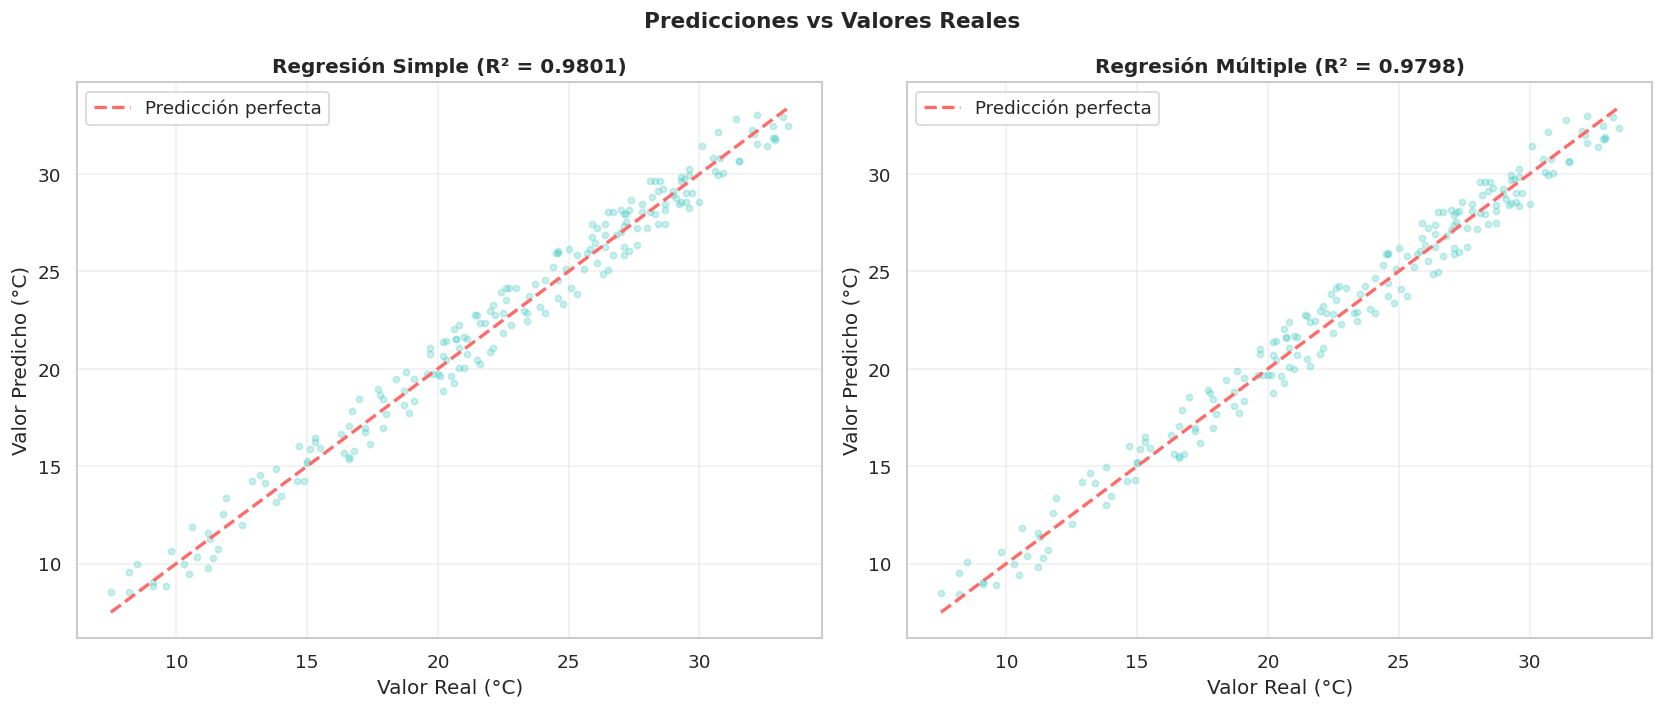

✅ Guardado: data/graficas/predicciones_vs_reales.png

🎓 Análisis completado — todas las gráficas en data/graficas/


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicciones vs Valores Reales', fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.30, s=14, color='#4ecdc4')
    ax.plot([minval, maxval], [minval, maxval], color='#ff6b6b',
            linewidth=2, linestyle='--', label='Predicción perfecta')
    r2_val = r2_score(y_real, y_pred)
    ax.set_title(f'{titulo} (R² = {r2_val:.4f})', fontweight='bold')
    ax.set_xlabel('Valor Real (°C)')
    ax.set_ylabel('Valor Predicho (°C)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/predicciones_vs_reales.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: data/graficas/predicciones_vs_reales.png')
print('\n🎓 Análisis completado — todas las gráficas en data/graficas/')